## Simple Linear Regression Model

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [17]:
df = pd.read_csv('E:\\Work\\OneDrive - Rapifuzz Private Limited\\Desktop\\Ayush\\Data_Science\\Machine Learing\\RegressionModel\\height-weight.csv')

In [18]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


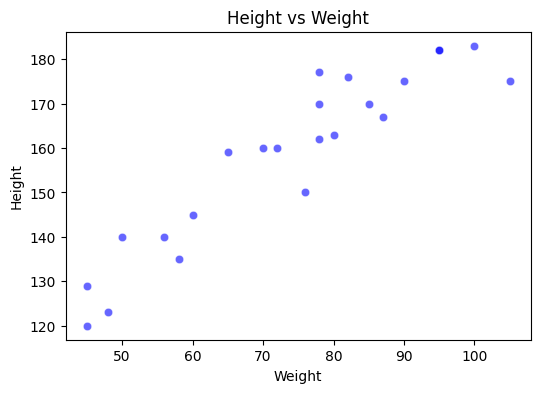

In [19]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x='Weight', y='Height', data=df, color='blue', alpha=0.6)
plt.title('Height vs Weight')
plt.show()

In [20]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


Text(0.5, 1.0, 'Pearson Correlation Heatmap')

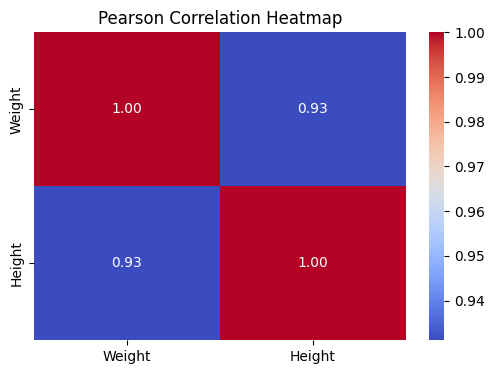

In [21]:
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Pearson Correlation Heatmap')

e:\Work\OneDrive - Rapifuzz Private Limited\Desktop\Ayush\Data_Science\venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
e:\Work\OneDrive - Rapifuzz Private Limited\Desktop\Ayush\Data_Science\venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)


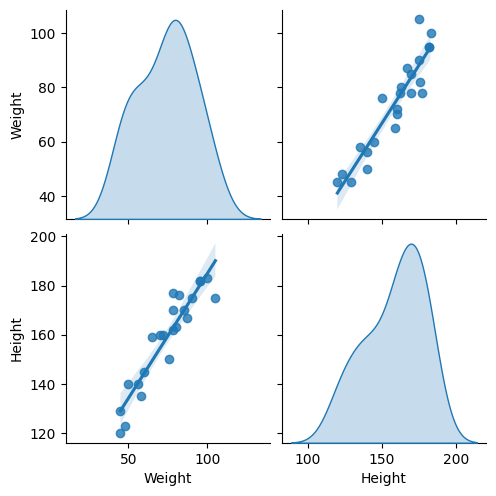

In [22]:
sns.pairplot(df, kind='reg', diag_kind='kde', markers='o', palette='coolwarm')
plt.show()

In [23]:
## Independent and Dependent Variables
X = df[['Weight']]   ### Idependent Variable should be in 2D array.
Y = df['Height']     ### This variable should be in 1D array.

In [24]:
X_series = df['Weight']
np.array(X_series).shape

(23,)

In [25]:
## trian-test split
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42)

In [26]:
X_train.shape

(17, 1)

In [27]:
## Strandardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

In [28]:
X_test = scaler.transform(X_test)

In [29]:
X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [32]:
## Applying Simple Linear Regression
from sklearn.linear_model import LinearRegression
model = LinearRegression(n_jobs=-1)

In [33]:
model.fit(X_train, Y_train)

LinearRegression(n_jobs=-1)

In [36]:
print("Coefficient or slope: ",model.coef_)
print("Intercept: ",model.intercept_)

Coefficient or slope:  [17.2982057]
Intercept:  156.47058823529412


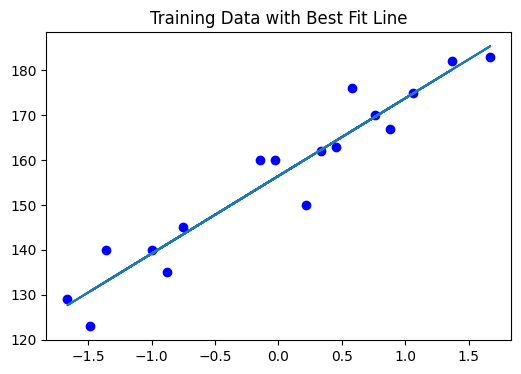

In [38]:
## plot training data and best fit line
plt.figure(figsize=(6, 4))
plt.scatter(X_train, Y_train, color='blue')
plt.plot(X_train, model.predict(X_train))
plt.title('Training Data with Best Fit Line')
plt.show()

### prediction of test data
1. predicted height output= intercept +coef_(Weights)
2. y_pred_test =156.470 + 17.29(X_test)

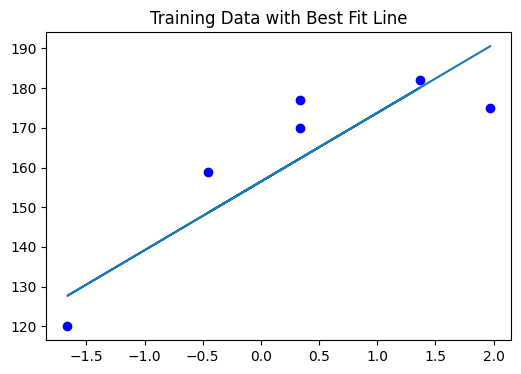

In [41]:
## plot testing data and best fit line
plt.figure(figsize=(6, 4))
plt.scatter(X_test, Y_test, color='blue')
plt.plot(X_test, model.predict(X_test))
plt.title('Training Data with Best Fit Line')
plt.show()

In [40]:
## Prediction for test data
Y_pred = model.predict(X_test)
print("Predicted Values: ", Y_pred)

Predicted Values:  [162.26499721 162.26499721 127.68347133 180.07972266 148.64197186
 190.55897293]


In [42]:
## Performane Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
mse = mean_squared_error(Y_test, Y_pred)
mae = mean_absolute_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
print("Mean Squared Error: ", mse)
print("Mean Absolute Error: ", mae)
print("Root Mean Squared Error: ", rmse)

Mean Squared Error:  114.84069295228699
Mean Absolute Error:  9.66512588679501
Root Mean Squared Error:  10.716374991212605


## R square 
Formula

**R^2 = 1 - SSR/SST**


R^2	=	coefficient of determination
SSR	=	sum of squares of residuals
SST	=	total sum of squares

In [43]:
## R-squared value
from sklearn.metrics import r2_score
score = r2_score(Y_test, Y_pred)
print("R-squared value: ", score)

R-squared value:  0.7360826717981276


**Adjusted R2 = 1 – [(1-R2)*(n-1)/(n-k-1)]**

where:

R2: The R2 of the model
n: The number of observations
k: The number of predictor variables

In [44]:
## Display ajusted R-squared value
1-((1-score)*(len(Y_test)-1)/(len(Y_test)-X_test.shape[1]-1))

0.6701033397476595

In [46]:
## OLS Technique for Linear Regression
import statsmodels.api as sm

In [47]:
ols_model = sm.OLS(Y_train, X_train).fit()

In [48]:
predicted = ols_model.predict(X_test)

In [49]:
print(predicted)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [50]:
print(ols_model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Wed, 25 Jun 2025   Prob (F-statistic):                       0.664
Time:                        12:21:39   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

e:\Work\OneDrive - Rapifuzz Private Limited\Desktop\Ayush\Data_Science\venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=17 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [53]:
## Prediction for a new data
model.predict(scaler.transform([[70]]))  # Predicting height for weight = 70 kg

e:\Work\OneDrive - Rapifuzz Private Limited\Desktop\Ayush\Data_Science\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([153.88159699])

## Multiple Linear Regression Model

In [54]:
data = pd.read_csv('economic_index.csv')
data.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [55]:
data.drop(['Unnamed: 0'], axis=1, inplace=True)  # Adjust column name as necessary

In [56]:
data.head()

,year,month,interest_rate,unemployment_rate,index_price
0,2017,12,2.75,5.3,1464
1,2017,11,2.50,5.3,1394
2,2017,10,2.50,5.3,1357
3,2017,9,2.50,5.3,1293
4,2017,8,2.50,5.4,1256


In [57]:
data.shape

(24, 5)

In [58]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               24 non-null     int64  
 1   month              24 non-null     int64  
 2   interest_rate      24 non-null     float64
 3   unemployment_rate  24 non-null     float64
 4   index_price        24 non-null     int64  
dtypes: float64(2), int64(3)
memory usage: 1.1 KB


In [59]:
data.drop(columns=['year','month'], axis=1, inplace=True)
data.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [60]:
data.duplicated().sum()

np.int64(0)

In [61]:
data.describe()

,interest_rate,unemployment_rate,index_price
count,24.000000,24.00000,24.000000
mean,2.072917,5.77500,1070.083333
std,0.349527,0.33002,210.735341
min,1.750000,5.30000,704.000000
25%,1.750000,5.50000,928.250000
50%,2.000000,5.85000,1061.000000
75%,2.500000,6.10000,1239.000000
max,2.750000,6.20000,1464.000000


In [62]:
data.shape

(24, 3)

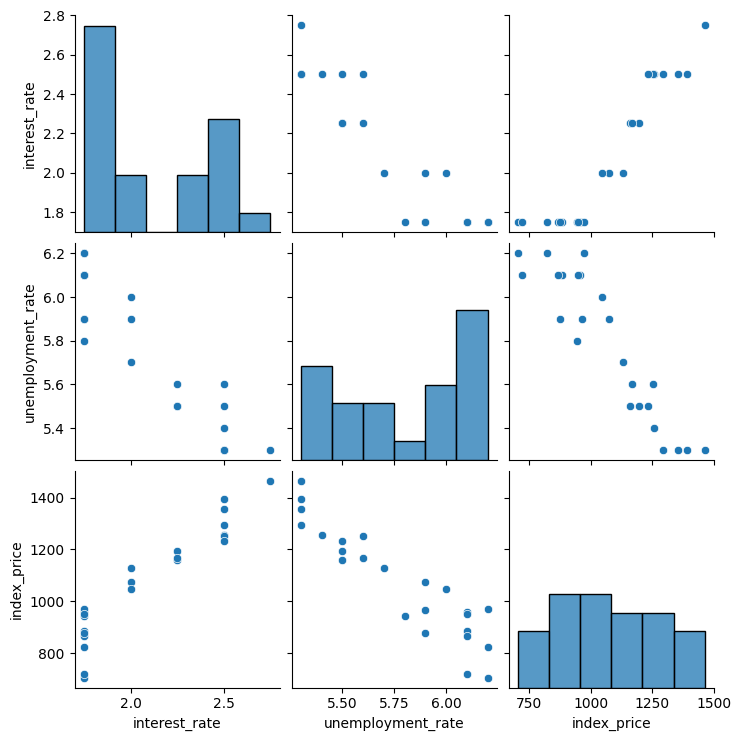

In [67]:
sns.pairplot(data)
plt.show()

In [66]:
data.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


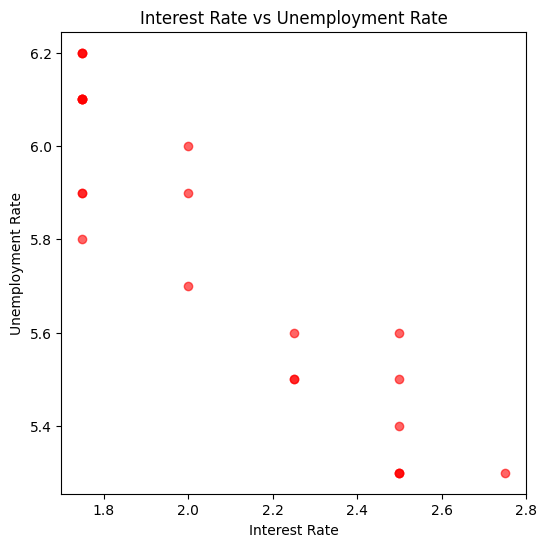

In [69]:
## Visulaize the data points
plt.figure(figsize=(6, 6))
plt.scatter(data['interest_rate'], data['unemployment_rate'], color='red', alpha=0.6)
plt.title('Interest Rate vs Unemployment Rate')
plt.xlabel('Interest Rate')
plt.ylabel('Unemployment Rate')
plt.show()

In [70]:
## Independent and Dependent Variables
x = data[['interest_rate', 'unemployment_rate']]  # Independent variable
y = data['index_price']  # Dependent variable

In [71]:
x.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [72]:
y

0     1464
1     1394
2     1357
3     1293
4     1256
5     1254
6     1234
7     1195
8     1159
9     1167
10    1130
11    1075
12    1047
13     965
14     943
15     958
16     971
17     949
18     884
19     866
20     876
21     822
22     704
23     719
Name: index_price, dtype: int64

In [73]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [74]:
x_train.shape

(18, 2)

In [75]:
y_train.shape

(18,)

In [76]:
x_test.shape

(6, 2)

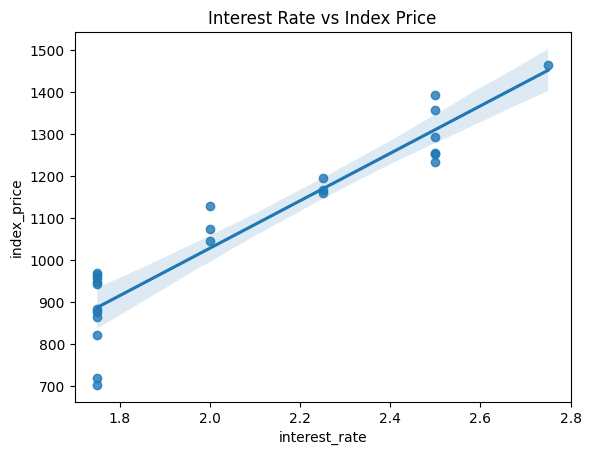

In [77]:
sns.regplot(x='interest_rate', y='index_price', data=data)
plt.title('Interest Rate vs Index Price')
plt.show()

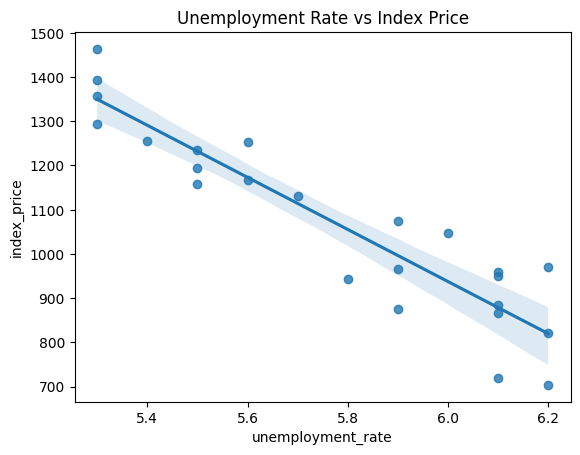

In [78]:
sns.regplot(x='unemployment_rate', y='index_price', data=data)
plt.title('Unemployment Rate vs Index Price')
plt.show()

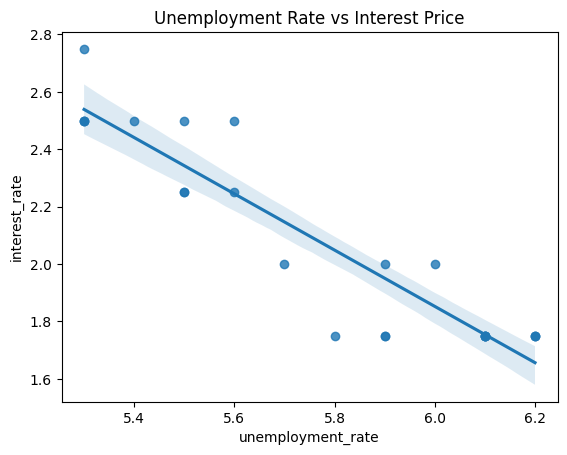

In [79]:
sns.regplot(x='unemployment_rate', y='interest_rate', data=data)
plt.title('Unemployment Rate vs Interest Price')
plt.show()

In [80]:
from sklearn.preprocessing import StandardScaler
stdscaler = StandardScaler()

In [81]:
x_train = stdscaler.fit_transform(x_train)
x_test = stdscaler.transform(x_test)

In [83]:
x_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [84]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()

In [85]:
regression.fit(x_train, y_train)

LinearRegression()

### Cross Validation

In [90]:
from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(regression, x_train, y_train, scoring='neg_mean_squared_error', cv=3)
validation_score

array([-4921.61331265, -7686.87497294, -5135.9962549 ])

In [89]:
np.mean(validation_score)

np.float64(-5914.828180162386)

In [91]:
## prediction
_pred = regression.predict(x_test)  

In [92]:
_pred

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

In [93]:
## Performane Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
mse = mean_squared_error(y_test, _pred)
mae = mean_absolute_error(y_test, _pred)
rmse = np.sqrt(mse)
print("Mean Squared Error: ", mse)
print("Mean Absolute Error: ", mae)
print("Root Mean Squared Error: ", rmse)

Mean Squared Error:  5793.762887712569
Mean Absolute Error:  59.935781523235484
Root Mean Squared Error:  76.11677139574805


In [94]:
from sklearn.metrics import r2_score
score = r2_score(y_test, _pred)
print("R-squared value: ", score)

R-squared value:  0.8278978091457145


In [96]:
ad_score = 1-((1-score)*(len(Y_test)-1)/(len(Y_test)-X_test.shape[1]-1))
print("Adjusted R-squared value: ", ad_score)

Adjusted R-squared value:  0.7848722614321432


In [97]:
from statsmodels.api import OLS
ols_model = OLS(y_train, x_train).fit()

In [99]:
ols_model.predict(x_test)

array([ 150.78325954, -231.79392541,  353.06855924, -195.73554836,
        -58.53452146,  114.72488249])

In [100]:
ols_model.summary()

e:\Work\OneDrive - Rapifuzz Private Limited\Desktop\Ayush\Data_Science\venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Wed, 25 Jun 2025   Prob (F-statistic):                       0.754
Time:                        15:02:28   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            88.2728    658.295      0.134      0.895   -1307.250    1483.796
x2          -116.2572    658.295     -0.177      0.862   -1511.780    1279.266
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [101]:
regression.coef_

array([  88.27275507, -116.25716066])

### Assumptions

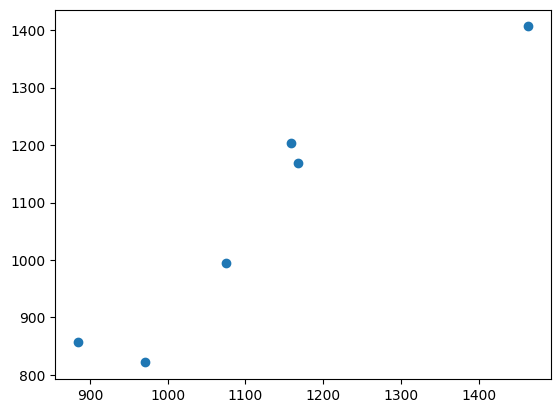

In [102]:
plt.scatter(y_test, _pred)
plt.show()

In [103]:
residual = y_test - _pred
print("Residuals: ", residual)

Residuals:  8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64


<Figure size 600x400 with 0 Axes>

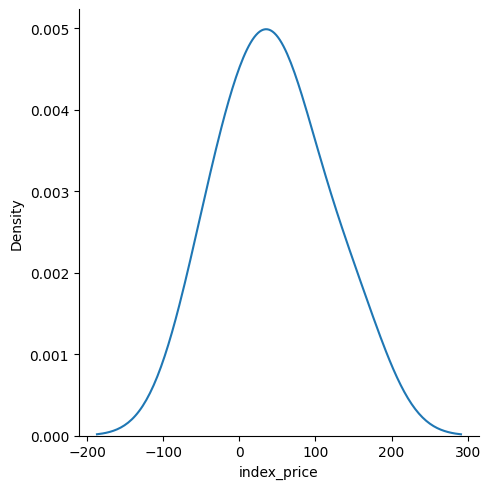

In [104]:
## Residual Analysis
plt.figure(figsize=(6, 4))
sns.displot(residual, kind='kde')
plt.show()

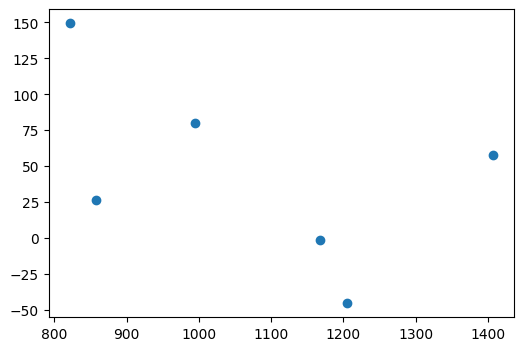

In [105]:
## Scatter plot of residuals and predicted values
plt.figure(figsize=(6, 4))
plt.scatter(_pred, residual)
plt.show()